In [ ]:
import os

gadf_base_dir = "../Raw_Images/GADF"
gasf_base_dir = "../Raw_Images/GASF"

print(os.listdir(gadf_base_dir))
print(os.listdir(gasf_base_dir))

['test', 'train', 'val']
['test', 'train', 'val']


In [31]:
gadf_train_dir = os.path.join(gadf_base_dir, "train")
gadf_val_dir = os.path.join(gadf_base_dir, "val")
gadf_test_dir = os.path.join(gadf_base_dir, "test")

gasf_train_dir = os.path.join(gasf_base_dir, "train")
gasf_val_dir = os.path.join(gasf_base_dir, "val")
gasf_test_dir = os.path.join(gasf_base_dir, "test")

In [32]:
print("GASF classes:", os.listdir(gasf_train_dir))
print("GADF classes:", os.listdir(gadf_train_dir))

GASF classes: ['B_007', 'B_014', 'B_021', 'IR_007', 'IR_014', 'IR_021', 'Normal', 'OR_007', 'OR_014', 'OR_021']
GADF classes: ['B_007', 'B_014', 'B_021', 'IR_007', 'IR_014', 'IR_021', 'Normal', 'OR_007', 'OR_014', 'OR_021']


In [33]:
import torch
import numpy as np
import pandas as pd
import torch.nn as nn
import torch.optim as optim
from PIL import Image
import random
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import confusion_matrix, classification_report
from torchvision import transforms

In [34]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [35]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

In [36]:
def get_samples(gasf_split_dir, gadf_split_dir):

    samples = []

    classes = sorted([
        d for d in os.listdir(gasf_split_dir)
        if os.path.isdir(os.path.join(gasf_split_dir, d))
    ])

    print(classes)

    for class_name in classes:

        gasf_class_dir = os.path.join(gasf_split_dir, class_name)

        gadf_class_dir = os.path.join(gadf_split_dir, class_name)

        images = sorted([
            i for i in os.listdir(gasf_class_dir)
            if i.lower().endswith(".png")
        ])

        for img in images:

            gasf_path = os.path.join(gasf_class_dir, img)

            gadf_path = os.path.join(gadf_class_dir, img)

            if not os.path.exists(gadf_path):

                print("Missing GADF image:", gadf_path)

                continue

            samples.append((gasf_path, gadf_path, class_name))

    return samples

In [37]:
train = get_samples(gasf_train_dir,gadf_train_dir)

val = get_samples(gasf_val_dir, gadf_val_dir)

test = get_samples(gasf_test_dir,gadf_test_dir)

['B_007', 'B_014', 'B_021', 'IR_007', 'IR_014', 'IR_021', 'Normal', 'OR_007', 'OR_014', 'OR_021']
['B_007', 'B_014', 'B_021', 'IR_007', 'IR_014', 'IR_021', 'Normal', 'OR_007', 'OR_014', 'OR_021']
['B_007', 'B_014', 'B_021', 'IR_007', 'IR_014', 'IR_021', 'Normal', 'OR_007', 'OR_014', 'OR_021']


In [38]:
print("TRAIN :", len(train))
print("VAL   :", len(val))
print("TEST  :", len(test))

TRAIN : 6604
VAL   : 681
TEST  : 681


In [39]:
class_to_idx = {}
idx = 0

classes = sorted([
    d for d in os.listdir(gasf_train_dir)
    if os.path.isdir(os.path.join(gasf_train_dir, d))
])

for cls in classes:
  class_to_idx[cls] = idx
  idx += 1

print(class_to_idx)

{'B_007': 0, 'B_014': 1, 'B_021': 2, 'IR_007': 3, 'IR_014': 4, 'IR_021': 5, 'Normal': 6, 'OR_007': 7, 'OR_014': 8, 'OR_021': 9}


In [40]:
transform = transforms.Compose([
    transforms.ToTensor()
])

In [41]:
class BearingData(Dataset):

  def __init__(self, features, labels, transform):
    self.features = features
    self.labels = labels
    self.transform = transform

  def __len__(self):
    return len(self.features)

  def __getitem__(self, idx):
    gasf_path, gadf_path, class_name = self.features[idx]

    gasf_image = Image.open(gasf_path).convert("L")
    gadf_image = Image.open(gadf_path).convert("L")

    if self.transform:
      gasf_image = self.transform(gasf_image)
      gadf_image = self.transform(gadf_image)

    image = torch.cat([gasf_image, gadf_image], dim=0)

    label = class_to_idx[class_name]

    return image, torch.tensor(label, dtype=torch.long)

In [42]:
train_dataset = BearingData(train, class_to_idx, transform)

val_dataset = BearingData(val, class_to_idx, transform)

test_dataset = BearingData(test, class_to_idx, transform)

In [43]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, pin_memory=True)

In [44]:
images, labels = next(iter(train_loader))

print("Image shape :", images.shape)
print("Label shape :", labels.shape)
print("Image dtype :", images.dtype)
print("Labels      :", labels[:10])

Image shape : torch.Size([32, 2, 224, 224])
Label shape : torch.Size([32])
Image dtype : torch.float32
Labels      : tensor([5, 9, 9, 1, 3, 9, 9, 6, 5, 1])


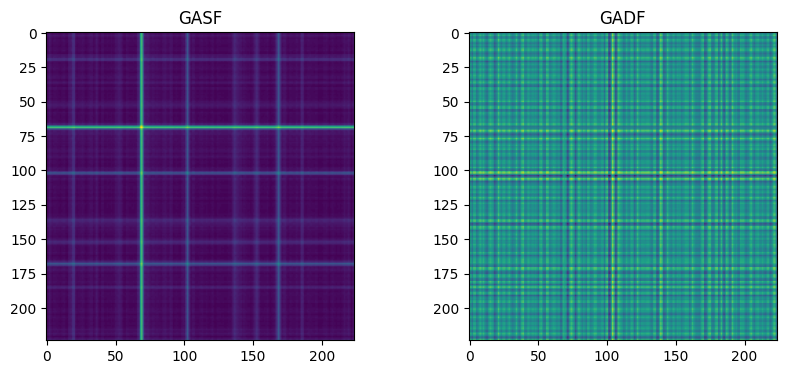

Label: 5


In [45]:
import matplotlib.pyplot as plt

inputs, labels = next(iter(train_loader))

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(inputs[0, 0])
plt.title("GASF")

plt.subplot(1, 2, 2)
plt.imshow(inputs[0, 1])
plt.title("GADF")

plt.show()

print("Label:", labels[0].item())

In [46]:
class FaultDiagnosis(nn.Module):

  def __init__(self):
    super().__init__()

    self.network = nn.Sequential(
        nn.Conv2d(in_channels=2, out_channels=32, kernel_size=3, padding='same'),
        nn.ReLU(),
        nn.BatchNorm2d(32),
        nn.MaxPool2d(kernel_size=2, stride=2),
        nn.Dropout(0.3),

        nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding='same'),
        nn.ReLU(),
        nn.BatchNorm2d(64),
        nn.MaxPool2d(kernel_size=2, stride=2),
        nn.Dropout(0.3),

        nn.Conv2d(64, 128, kernel_size=3, padding='same'),
        nn.ReLU(),
        nn.BatchNorm2d(128),
        nn.MaxPool2d(2, 2)
    )

    self.classifier = nn.Sequential(
        nn.AdaptiveAvgPool2d((1, 1)),

        nn.Flatten(),

        nn.Linear(in_features=128, out_features=64),
        nn.ReLU(),
        nn.Dropout(0.3),

        nn.Linear(in_features=64, out_features=32),
        nn.ReLU(),
        nn.Dropout(0.3),

        nn.Linear(in_features=32, out_features=10)
    )

  def forward(self, x):
    x = self.network(x)
    x = self.classifier(x)
    return x

In [47]:
model = FaultDiagnosis().to(device)

In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()

epochs = 100

In [49]:
train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

best_val_accuracy = 0.0

In [ ]:
print("Training started")

for epoch in range(epochs):

  model.train()

  correct = 0
  total = 0
  running_loss = 0.0

  for inputs, labels in train_loader:
    inputs = inputs.to(device)
    labels = labels.to(device)

    optimizer.zero_grad()

    outputs = model(inputs)

    loss = criterion(outputs, labels)

    loss.backward()
    
    optimizer.step()

    running_loss += loss.item()*inputs.size(0)
    _, predicted = torch.max(outputs, 1)

    total += labels.size(0)
    correct += (predicted == labels).sum().item()

  train_loss = running_loss / total
  train_accuracy = 100*correct / total

  print("\nValidation started\n")

  model.eval()

  with torch.no_grad():
    correct = 0
    total = 0
    running_loss = 0.0

    for inputs, labels in val_loader:
      inputs = inputs.to(device)
      labels = labels.to(device)

      outputs = model(inputs)

      loss = criterion(outputs, labels)

      running_loss += loss.item()*inputs.size(0)
      _, predicted = torch.max(outputs, 1)

      total += labels.size(0)
      correct += (predicted == labels).sum().item()

    val_loss = running_loss / total
    val_accuracy = 100*correct / total

    if val_accuracy > best_val_accuracy:

      best_val_accuracy = val_accuracy

      torch.save(model.state_dict(),"raw_2channel_best_model.pth")

      print(f"New best validation accuracy: {best_val_accuracy:.2f}%")

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)

    print(f"Epoch [{epoch+1}/{epochs}] ")
    print(f"Train Loss: {train_loss:.4f} ")
    print(f"Train Acc: {train_accuracy:.2f}% ")
    print(f"Val Loss: {val_loss:.4f} ")
    print(f"Val Acc: {val_accuracy:.2f}%")

print("Training complete .....")

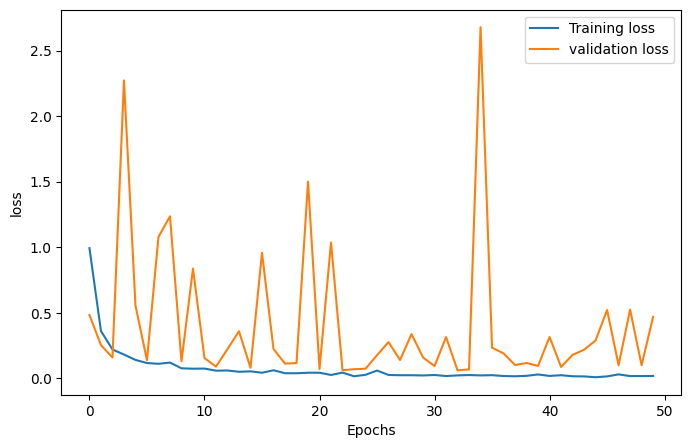

In [59]:
plt.figure(figsize=(8, 5))

plt.plot(train_losses, label='Training loss')
plt.plot(val_losses, label='validation loss')

plt.xlabel('Epochs')
plt.ylabel('loss')

plt.legend()
plt.show()

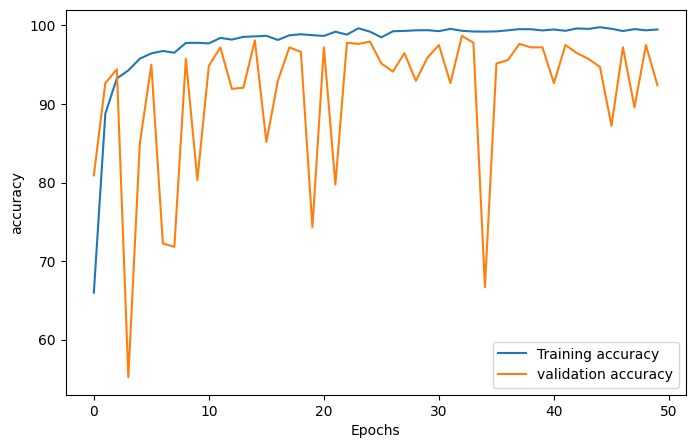

In [60]:
plt.figure(figsize=(8, 5))

plt.plot(train_accuracies, label='Training accuracy')
plt.plot(val_accuracies, label='validation accuracy')

plt.xlabel('Epochs')
plt.ylabel('accuracy')

plt.legend()
plt.show()

In [53]:
torch.save(model.state_dict(), 'raw_2channel_final_mixed_model.pth')
print("Model saved for epoch 100")

Model saved for epoch 100


In [ ]:
best_model = FaultDiagnosis().to(device)

best_model.load_state_dict(torch.load("../models/raw_2channel_best_model.pth", weights_only=True))

<All keys matched successfully>

In [55]:
print("Training started")

best_model.eval()

test_correct = 0
test_total = 0

with torch.no_grad():

  for inputs, labels in train_loader:
    inputs = inputs.to(device)
    labels = labels.to(device)

    outputs = best_model(inputs)

    _, predicted = torch.max(outputs, 1)

    test_total += labels.size(0)
    test_correct += (predicted == labels).sum().item()

  test_accuracy = 100*test_correct / test_total
  print(f"Training accuracy : {test_accuracy:.2f}%")

Training started
Training accuracy : 99.92%


In [56]:
print("Validation started")

best_model.eval()

test_correct = 0
test_total = 0

with torch.no_grad():

  for inputs, labels in val_loader:
    inputs = inputs.to(device)
    labels = labels.to(device)

    outputs = best_model(inputs)

    _, predicted = torch.max(outputs, 1)

    test_total += labels.size(0)
    test_correct += (predicted == labels).sum().item()

  test_accuracy = 100*test_correct / test_total
  print(f"Validation accuracy : {test_accuracy:.2f}%")

Validation started
Validation accuracy : 98.68%


In [57]:
print("Testing started")

best_model.eval()

test_correct = 0
test_total = 0

all_predictions = []
all_labels = []

with torch.no_grad():

  for inputs, labels in test_loader:
    inputs = inputs.to(device)
    labels = labels.to(device)

    outputs = best_model(inputs)

    _, predicted = torch.max(outputs, 1)

    test_total += labels.size(0)
    test_correct += (predicted == labels).sum().item()

    all_labels.extend(labels.cpu().numpy())
    all_predictions.extend(predicted.cpu().numpy())


  test_accuracy = 100*test_correct / test_total
  print(f"Test accuracy : {test_accuracy:.2f}%")

  all_labels = np.array(all_labels)

  all_predictions = np.array(all_predictions)

  cm = confusion_matrix(
    all_labels,
    all_predictions
  )

  print(cm)

Testing started
Test accuracy : 98.97%
[[68  0  0  0  0  0  0  0  0  0]
 [ 1 65  0  0  0  1  0  0  1  0]
 [ 4  0 64  0  0  0  0  0  0  0]
 [ 0  0  0 69  0  0  0  0  0  0]
 [ 0  0  0  0 68  0  0  0  0  0]
 [ 0  0  0  0  0 68  0  0  0  0]
 [ 0  0  0  0  0  0 68  0  0  0]
 [ 0  0  0  0  0  0  0 68  0  0]
 [ 0  0  0  0  0  0  0  0 68  0]
 [ 0  0  0  0  0  0  0  0  0 68]]


In [58]:
class_names = [
    "B_007",
    "B_014",
    "B_021",
    "IR_007",
    "IR_014",
    "IR_021",
    "Normal",
    "OR_007",
    "OR_014",
    "OR_021",
]

print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=class_names,
        digits=4
    )
)

              precision    recall  f1-score   support

       B_007     0.9315    1.0000    0.9645        68
       B_014     1.0000    0.9559    0.9774        68
       B_021     1.0000    0.9412    0.9697        68
      IR_007     1.0000    1.0000    1.0000        69
      IR_014     1.0000    1.0000    1.0000        68
      IR_021     0.9855    1.0000    0.9927        68
      Normal     1.0000    1.0000    1.0000        68
      OR_007     1.0000    1.0000    1.0000        68
      OR_014     0.9855    1.0000    0.9927        68
      OR_021     1.0000    1.0000    1.0000        68

    accuracy                         0.9897       681
   macro avg     0.9903    0.9897    0.9897       681
weighted avg     0.9903    0.9897    0.9897       681

